# CodeCloneValidation

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

2025-12-09 13:54:43.427148: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 13:54:43.451424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
print("--- Chargement du dataset ---")
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

train_data = ds['train']
val_data = ds['validation']
test_data = ds['test']

# Fonction pour combiner les deux codes en une seule chaîne
def combine_funcs(example):
    # On ajoute des balises pour aider le modèle à distinguer les deux fonctions
    return example['func1'] + " <SEP> " + example['func2']

print("--- Préparation du texte ---")
# On utilise tout le dataset (possible grâce à l'optimisation mémoire)
X_train_text = [combine_funcs(train_data[i]) for i in range(len(train_data))]
y_train = np.array(train_data['label'], dtype=np.float32)

X_val_text = [combine_funcs(val_data[i]) for i in range(len(val_data))]
y_val = np.array(val_data['label'], dtype=np.float32)

X_test_text = [combine_funcs(test_data[i]) for i in range(len(test_data))]
y_test = np.array(test_data['label'], dtype=np.float32)

print(f"Train shape: {len(X_train_text)}")
print(f"Val shape: {len(X_val_text)}")
print(f"Test shape: {len(X_test_text)}")

--- Chargement du dataset ---
--- Préparation du texte ---
Train shape: 901028
Val shape: 415416
Test shape: 415416


In [3]:
# ==========================================
# 2. VECTORISATION (TF-IDF)
# ==========================================
print("\n--- Vectorisation TF-IDF ---")

# Configuration du vectoriseur
# max_features=20000 : On ne garde que les 20k mots les plus importants pour économiser la RAM
vectorizer = TfidfVectorizer(
    max_features=20000, 
    dtype=np.float32  # Utilise moins de mémoire que le float64 par défaut
)

print("1. Apprentissage du vocabulaire et transformation du Train (fit_transform)...")
# On apprend le vocabulaire sur le train et on transforme en même temps
X_train_sparse = vectorizer.fit_transform(X_train_text)

print(f"   -> Dimensions Train: {X_train_sparse.shape}")

print("2. Transformation du Validation set...")
# On utilise le vocabulaire appris pour transformer la validation (sans réapprendre)
X_val_sparse = vectorizer.transform(X_val_text)

print("3. Transformation du Test set...")
# Idem pour le test
X_test_sparse = vectorizer.transform(X_test_text)

print(f"\n--- Résumé des dimensions ---")
print(f"Train Sparse: {X_train_sparse.shape}")
print(f"Val Sparse  : {X_val_sparse.shape}")
print(f"Test Sparse : {X_test_sparse.shape}")
print("La vectorisation est terminée. Les données sont prêtes pour le générateur.")


--- Vectorisation TF-IDF ---
1. Apprentissage du vocabulaire et transformation du Train (fit_transform)...
   -> Dimensions Train: (901028, 20000)
2. Transformation du Validation set...
3. Transformation du Test set...

--- Résumé des dimensions ---
Train Sparse: (901028, 20000)
Val Sparse  : (415416, 20000)
Test Sparse : (415416, 20000)
La vectorisation est terminée. Les données sont prêtes pour le générateur.


In [5]:
# ==========================================
# 3. GÉNÉRATEUR DE DONNÉES (L'OPTIMISATION CLÉ)
# ==========================================
class SparseDataGenerator(keras.utils.Sequence):
    """
    Génère des batchs de données pour Keras à partir de matrices sparse.
    Permet d'utiliser peu de RAM tout en entraînant sur des millions de données.
    """
    def __init__(self, x_sparse, y, batch_size=128, shuffle=True):
        self.x_sparse = x_sparse
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(x_sparse.shape[0])
        self.on_epoch_end()

    def __len__(self):
        # Nombre de pas par époque
        return int(np.ceil(self.x_sparse.shape[0] / self.batch_size))

    def __getitem__(self, index):
        # Sélection des indices pour ce batch
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, self.x_sparse.shape[0])
        batch_indices = self.indices[start_idx:end_idx]
        
        # Conversion Sparse -> Dense uniquement pour ce petit morceau
        # C'est ici que la magie opère pour sauver la RAM
        batch_x = self.x_sparse[batch_indices].toarray()
        batch_y = self.y[batch_indices]
        
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Création des générateurs
BATCH_SIZE = 256 # On peut monter à 256 ou 512 avec 64Go de RAM
train_gen = SparseDataGenerator(X_train_sparse, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen = SparseDataGenerator(X_val_sparse, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_gen = SparseDataGenerator(X_test_sparse, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# ==========================================
# 4. ARCHITECTURE DU MODÈLE
# ==========================================
print("\n--- Construction du Modèle ---")

input_dim = X_train_sparse.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    # BatchNormalization remplace StandardScaler ici.
    # Elle normalise les données par batch directement dans le GPU/CPU.
    layers.BatchNormalization(),
    
    # Bloc 1
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(), # Stabilise l'apprentissage
    layers.Dropout(0.4),
    
    # Bloc 2
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Bloc 3
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    # Sortie
    layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
)

model.summary()


--- Construction du Modèle ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 20000)          │        80,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,240,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,487,937 (40.01 MB)

 Trainable params: 10,446,401 (39.85 MB)

 Non-trainable params: 41,536 (162.25 KB)

In [7]:
# ==========================================
# 5. ENTRAÎNEMENT
# ==========================================
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_sparse_model.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

print("\n--- Début de l'entraînement ---")
# Note: On passe les générateurs (train_gen) au lieu des arrays bruts
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, # Souvent suffisant avec cette quantité de données
    callbacks=callbacks_list,
    verbose=1
)


--- Début de l'entraînement ---
Epoch 1/20


/opt/local/stow/conda/miniforge3/envs/cremi/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3520/3520 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9243 - auc: 0.9766 - loss: 0.5613 - precision: 0.9238 - recall: 0.9260
Epoch 1: val_auc improved from None to 0.97312, saving model to best_sparse_model.keras
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 252s 71ms/step - accuracy: 0.9490 - auc: 0.9905 - loss: 0.3681 - precision: 0.9476 - recall: 0.9506 - val_accuracy: 0.9520 - val_auc: 0.9731 - val_loss: 0.3136 - val_precision: 0.7759 - val_recall: 0.8856 - learning_rate: 0.0010
Epoch 2/20
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9660 - auc: 0.9952 - loss: 0.2453 - precision: 0.9633 - recall: 0.9691
Epoch 2: val_auc improved from 0.97312 to 0.98112, saving model to best_sparse_model.keras
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 254s 72ms/step - accuracy: 0.9682 - auc: 0.9957 - loss: 0.2299 - precision: 0.9653 - recall: 0.9714 - val_accuracy: 0.9543 - val_auc: 0.9811 - val_loss: 0.2599 - val_precision: 0.7737 - val_recall: 0.9149 - learning_rate: 0.0010
Epoch 3/20
3520/3520 ━━━━━━━━━━━


--- Évaluation sur le Test Set ---
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9625 - auc: 0.9654 - loss: 0.2251 - precision: 0.8333 - recall: 0.9070

Résultats finaux :
loss: 0.2251
compile_metrics: 0.9625
F1-Score: 0.8686

--- Génération du rapport détaillé ---
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step
              precision    recall  f1-score   support

   Not Clone       0.99      0.97      0.98    358596
       Clone       0.83      0.91      0.87     56820

    accuracy                           0.96    415416
   macro avg       0.91      0.94      0.92    415416
weighted avg       0.96      0.96      0.96    415416



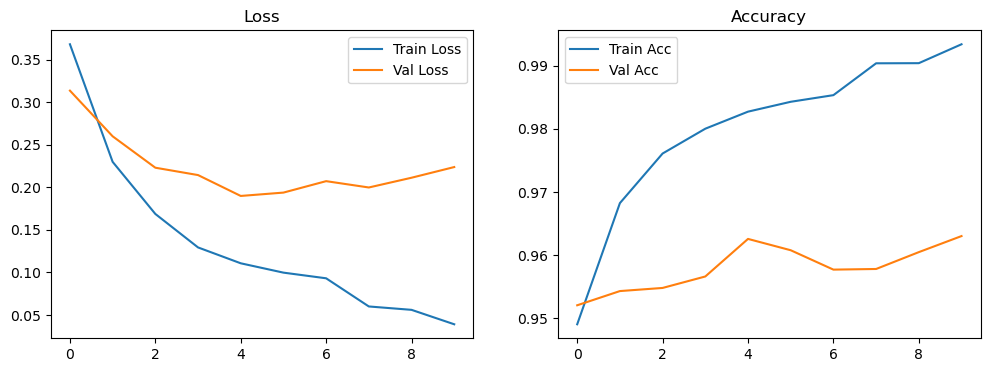

In [8]:
# ==========================================
# 6. ÉVALUATION ET VISUALISATION
# ==========================================
print("\n--- Évaluation sur le Test Set ---")
results = model.evaluate(test_gen, verbose=1)

print("\nRésultats finaux :")
for metric, value in zip(model.metrics_names, results):
    print(f"{metric}: {value:.4f}")

# Calcul du F1-Score
precision = results[2] # index 2 car loss=0, acc=1, prec=2
recall = results[3]
f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
print(f"F1-Score: {f1:.4f}")

# Matrice de confusion
# Pour la matrice, on doit prédire sur tout le test set
print("\n--- Génération du rapport détaillé ---")
y_pred_proba = model.predict(test_gen).flatten()
y_pred_class = (y_pred_proba > 0.5).astype(int)

# Attention : y_test est dans l'ordre, mais assurons-nous que le générateur n'a pas mélangé (shuffle=False plus haut)
print(classification_report(y_test, y_pred_class, target_names=['Not Clone', 'Clone']))

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Génerer les courbes ROC